In [21]:
import math
from pathlib import Path

RESULT_DIR = Path("../result/")

In [22]:
def calc_dist(p1: tuple, p2: tuple) -> float:
    return math.dist(p1, p2)


class EnvOffline:
    def __init__(self, input_file_path: str, output_file_path: str):
        with open(input_file_path) as f:
            lines = f.readlines()
            N, M, Q, L, W = map(int, lines[0].split())
            G = list(map(int, lines[1].split()))
            rectangles = []
            for l in range(2, 2 + N):
                rectangles.append(list(map(int, lines[l].split())))
            coordinates = []
            for l in range(2 + N, 2 + N + N):
                coordinates.append(tuple(map(int, lines[l].split())))

        self.N, self.M, self.Q, self.L, self.W = N, M, Q, L, W
        self.G = G
        self.rectangles = rectangles
        self.coordinates = coordinates
        self.cneter_points = [((l + r) / 2, (c + d) / 2) for l, r, c, d in rectangles]
        self._query_history: list[str] = []

        self.input_file_path = input_file_path
        self.output_file_path = output_file_path

    def query(self, c_list: list[int]) -> list[tuple[int, int]]:
        query_str = " ".join(["?", str(len(c_list)), *map(str, c_list)])
        self._query_history.append(query_str)

        now_graph: dict[int, list] = {v: [] for v in c_list}
        for c1 in c_list:
            for c2 in c_list:
                if c1 == c2:
                    continue
                x1, y1 = self.coordinates[c1]
                x2, y2 = self.coordinates[c2]
                dist = calc_dist((x1, y1), (x2, y2))
                now_graph[c1].append((c2, dist))
                now_graph[c2].append((c1, dist))

        ans_edges, ans_v = prim(now_graph)
        return ans_edges

    def answer(
        self,
        groups: list[list[int]],
        edges: list[list[tuple[int, int]]],
    ):
        cost = 0.0
        ans_str = "!\n"
        for i in range(len(groups)):
            ans_str += " ".join(map(str, groups[i])) + "\n"
            for e in edges[i]:
                ans_str += " ".join(map(str, e)) + "\n"
                dist = calc_dist(self.coordinates[e[0]], self.coordinates[e[1]])
                cost += dist

        for query_str in self._query_history:
            ans_str += query_str + "\n"

        with open(self.output_file_path, "w") as f:
            f.write(ans_str)

        return cost

In [23]:
def read_txt(txt_path):
    with open(txt_path, "r") as f:
        lines = f.readlines()
        costs = [float(line.split()[1]) for line in lines[1:]]
    return costs

In [24]:
FILE_NUM = 100

envs = []
for file_num in range(FILE_NUM):
    input_file_path = f"../in/{file_num:04d}.txt"
    output_file_path = f"../out/{file_num:04d}.txt"
    #####
    env = EnvOffline(input_file_path, output_file_path)
    envs.append(env)


In [25]:
import numpy as np

base_cost_txt = RESULT_DIR / "cpp_base.txt"
target_cost_txt = RESULT_DIR / "cpp_fast3.txt"
target_cost_txt2 = RESULT_DIR / "cpp_fast4.txt"

base_costs = np.array(read_txt(base_cost_txt))
target_costs = np.array(read_txt(target_cost_txt))
target_costs2 = np.array(read_txt(target_cost_txt2))
ax2_vals = np.array([env.L for env in envs])

In [26]:
def atcoder_score(base_costs, target_costs):
    base_costs = np.array(base_costs)
    target_costs = np.array(target_costs)
    score = 0
    for i in range(len(base_costs)):
        mul = 10**9
        score += base_costs[i] / target_costs[i] * mul
    return score / 2

In [27]:
print("base_costs avg", base_costs.mean())
print("target_costs avg", target_costs.mean())
print("target_costs2 avg", target_costs2.mean())

base_costs avg 157733.61
target_costs avg 210417.5
target_costs2 avg 236170.46


In [28]:
print("target1 estimate atcoder score", atcoder_score(base_costs, target_costs))
print("target2 estimate atcoder score", atcoder_score(base_costs, target_costs2))

target1 estimate atcoder score 39712509290.66844
target2 estimate atcoder score 36993531547.81819


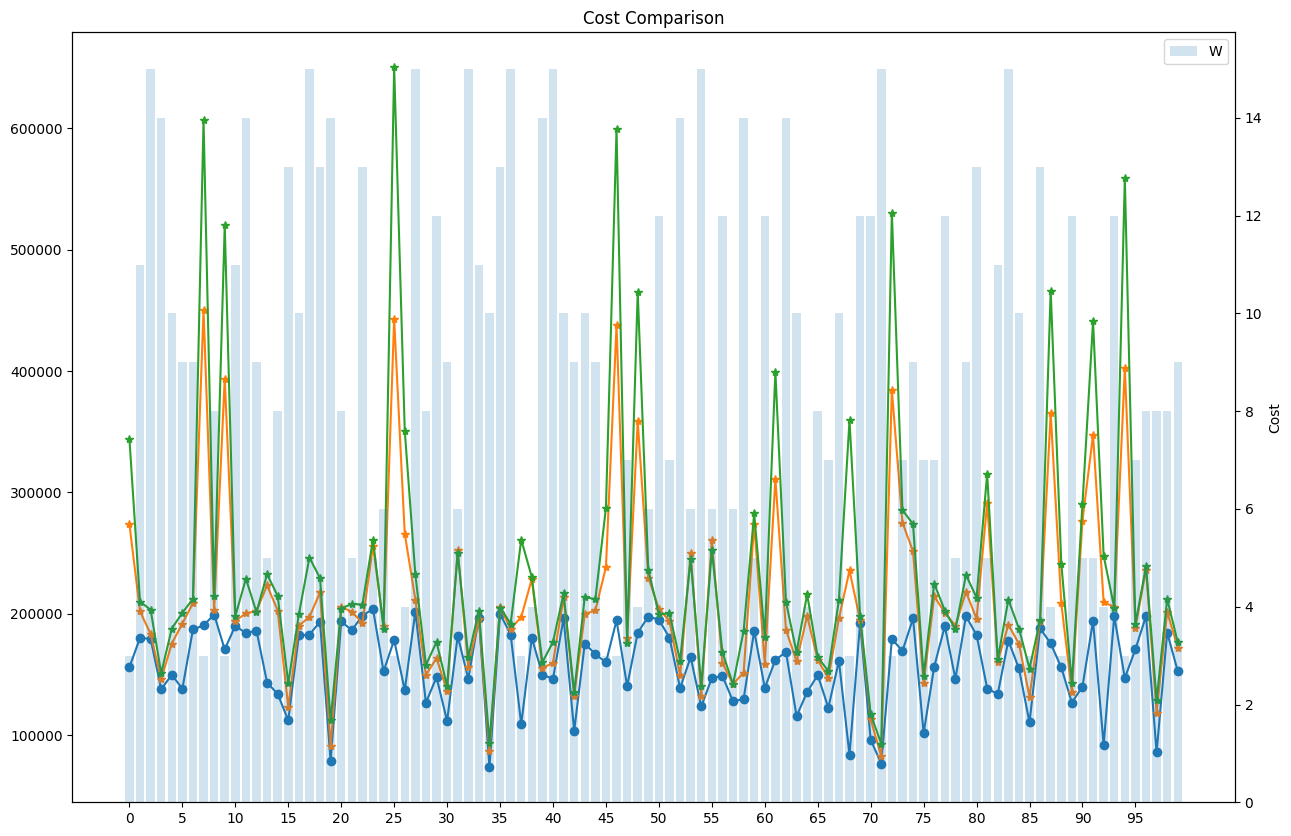

In [29]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(15, 10))
ax1 = fig.add_subplot(111)
ax1.plot(range(FILE_NUM), base_costs, label="best", marker="o")
ax1.plot(range(FILE_NUM), target_costs, label="target1", marker="*")
ax1.plot(range(FILE_NUM), target_costs2, label="targe2", marker="*")

ax2 = ax1.twinx()
ax2.bar(range(FILE_NUM), ax2_vals, alpha=0.2, label="W")

plt.xticks(range(0, FILE_NUM, 5))
plt.xlabel("File Number")
plt.ylabel("Cost")
plt.title("Cost Comparison")
plt.legend()
plt.show()

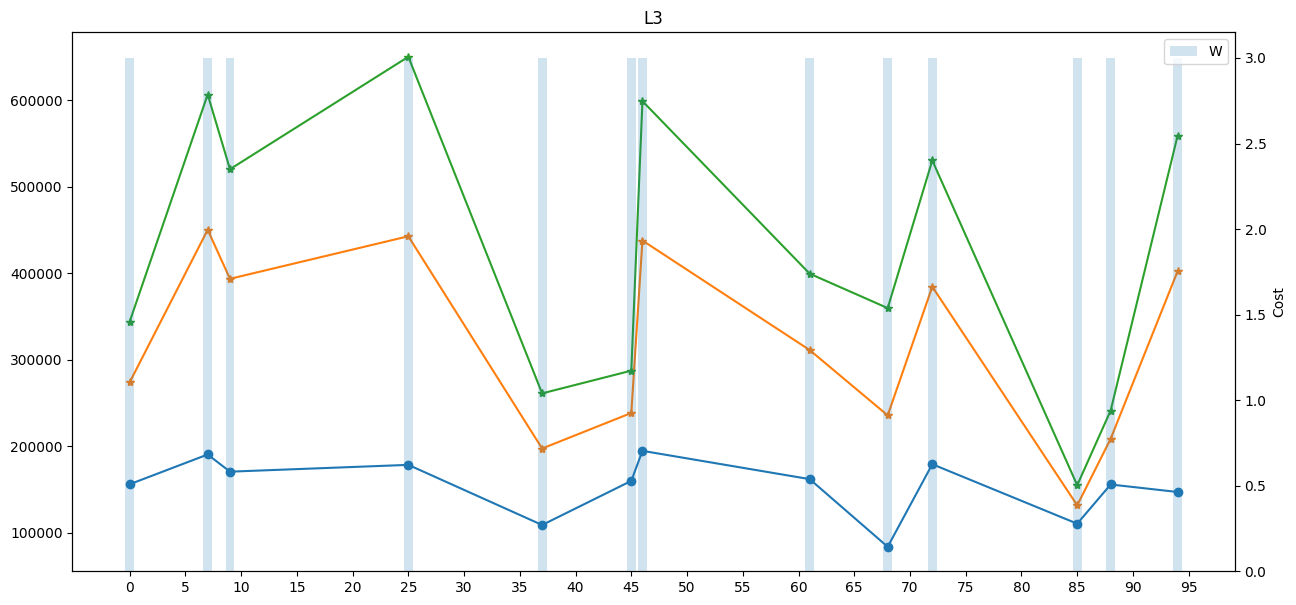

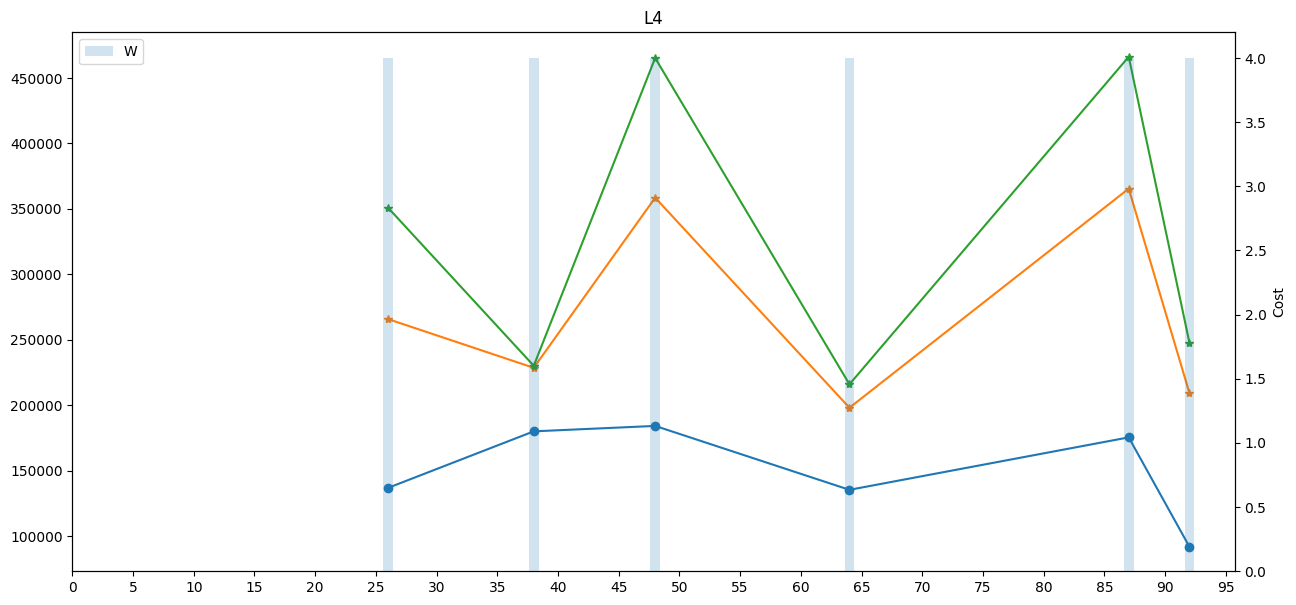

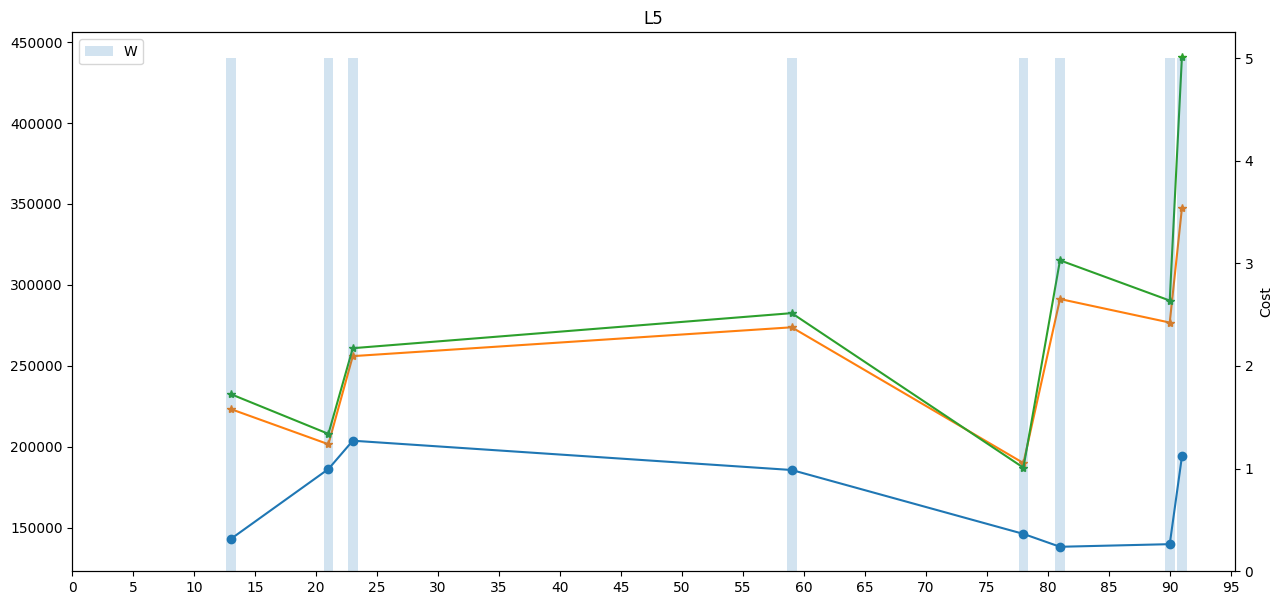

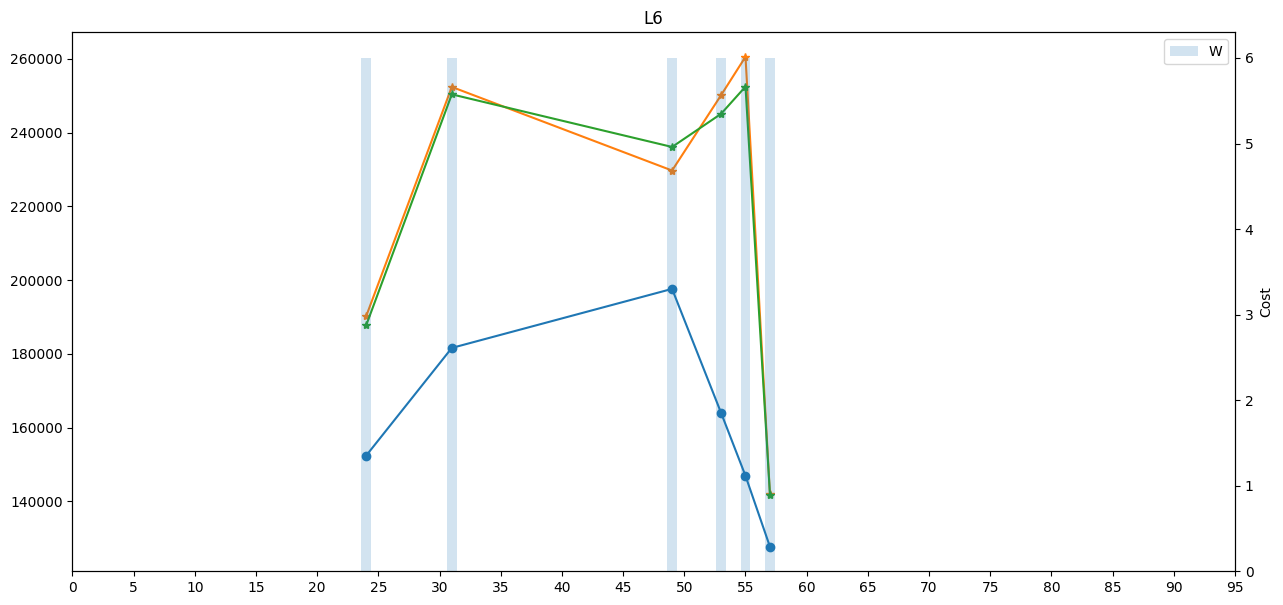

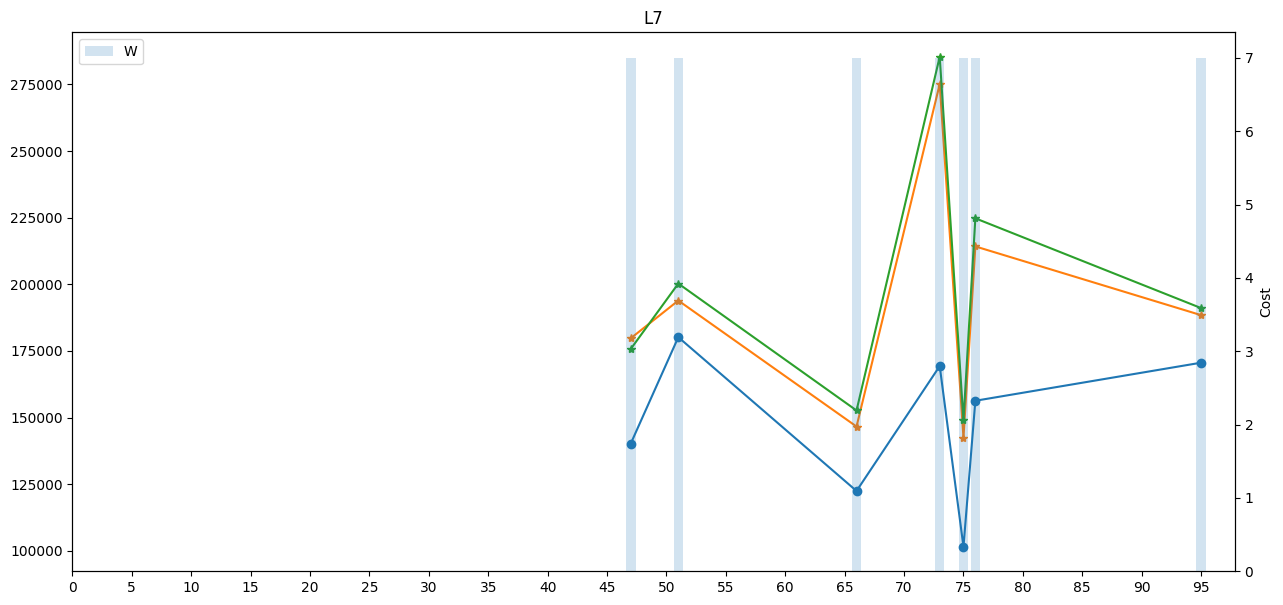

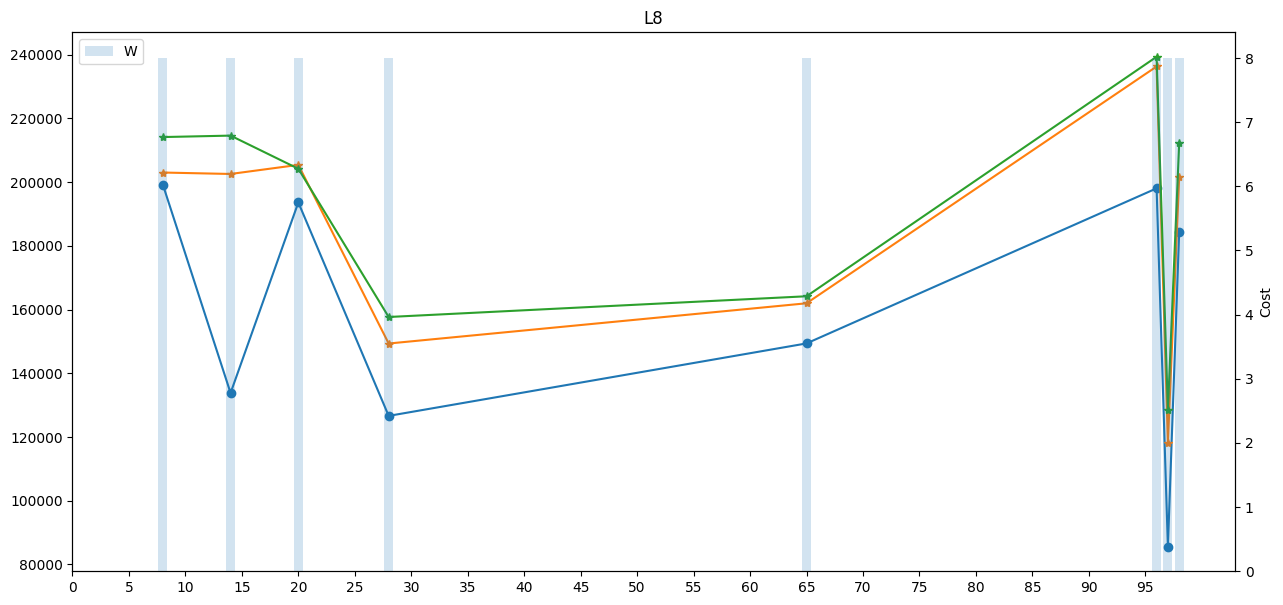

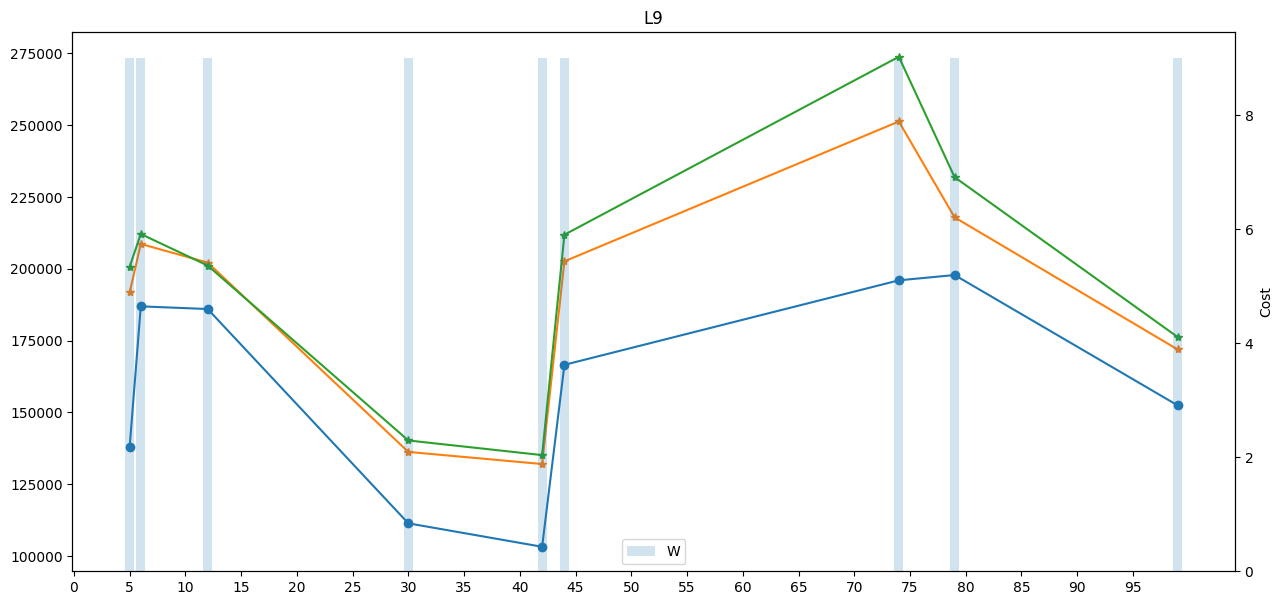

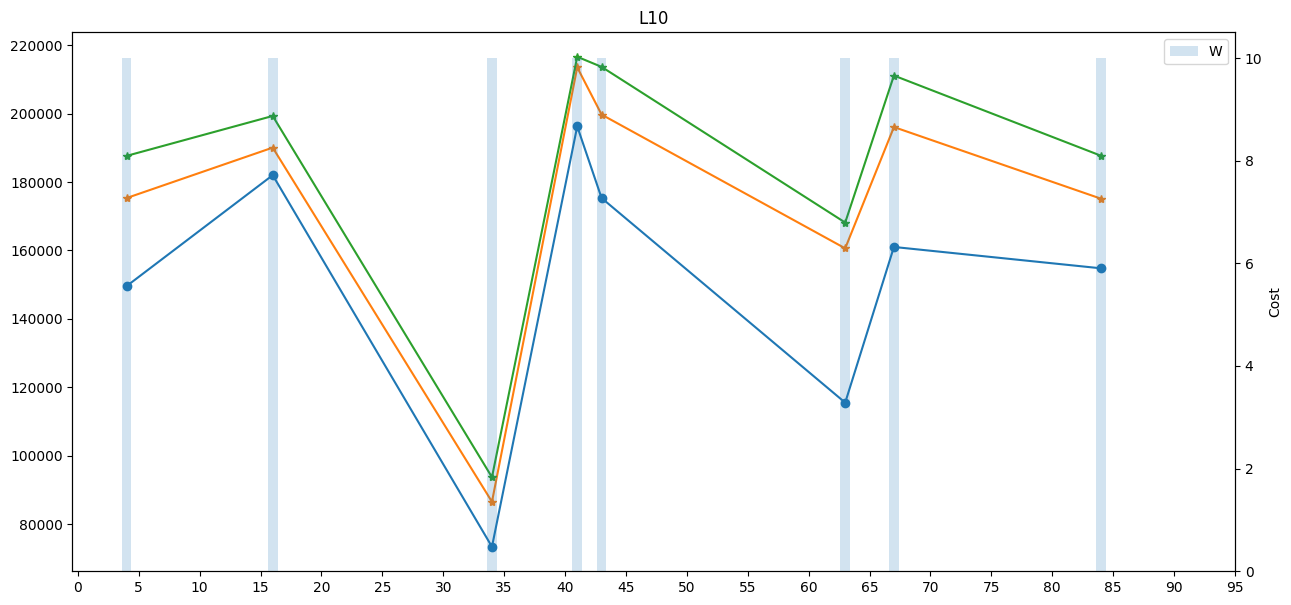

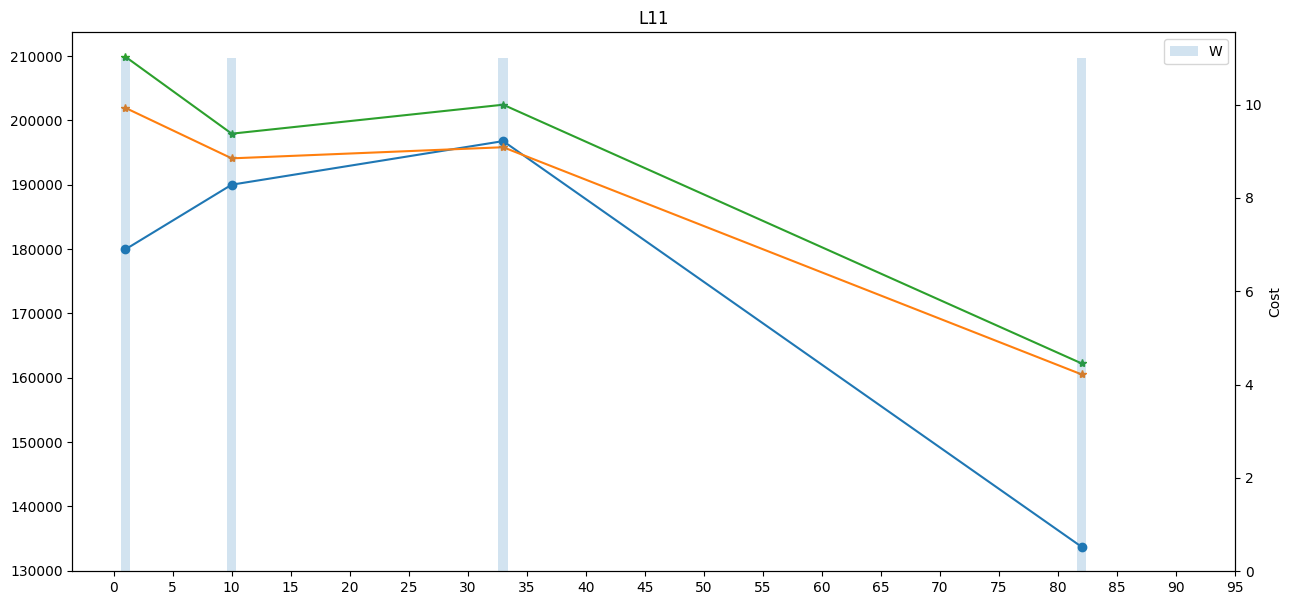

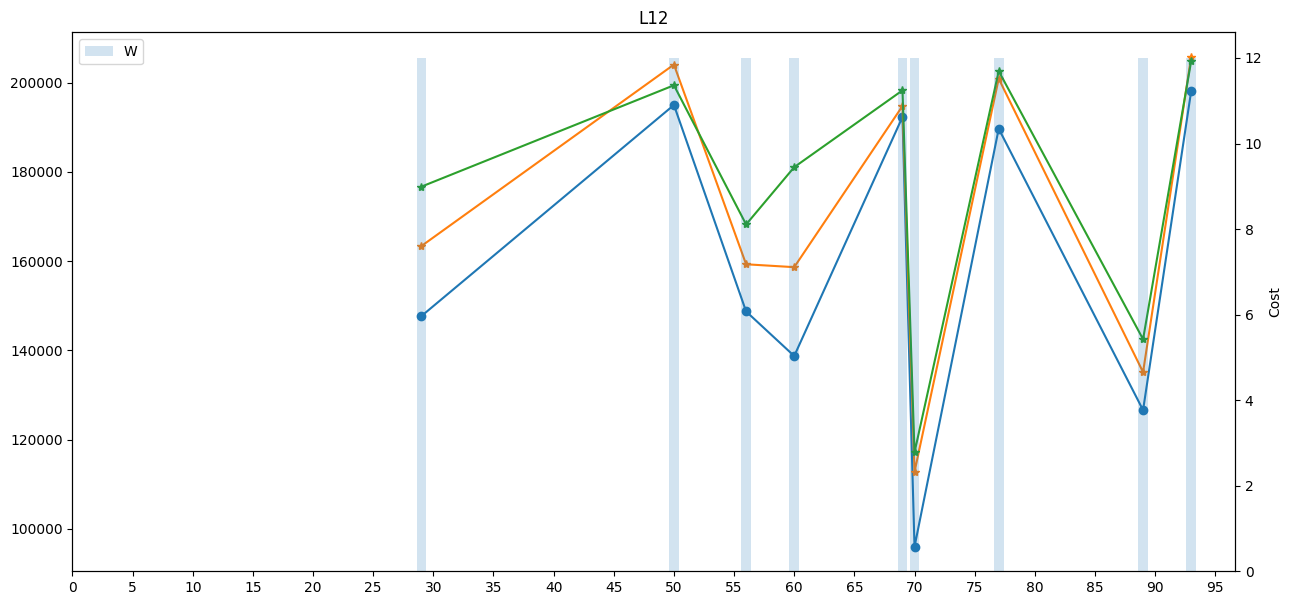

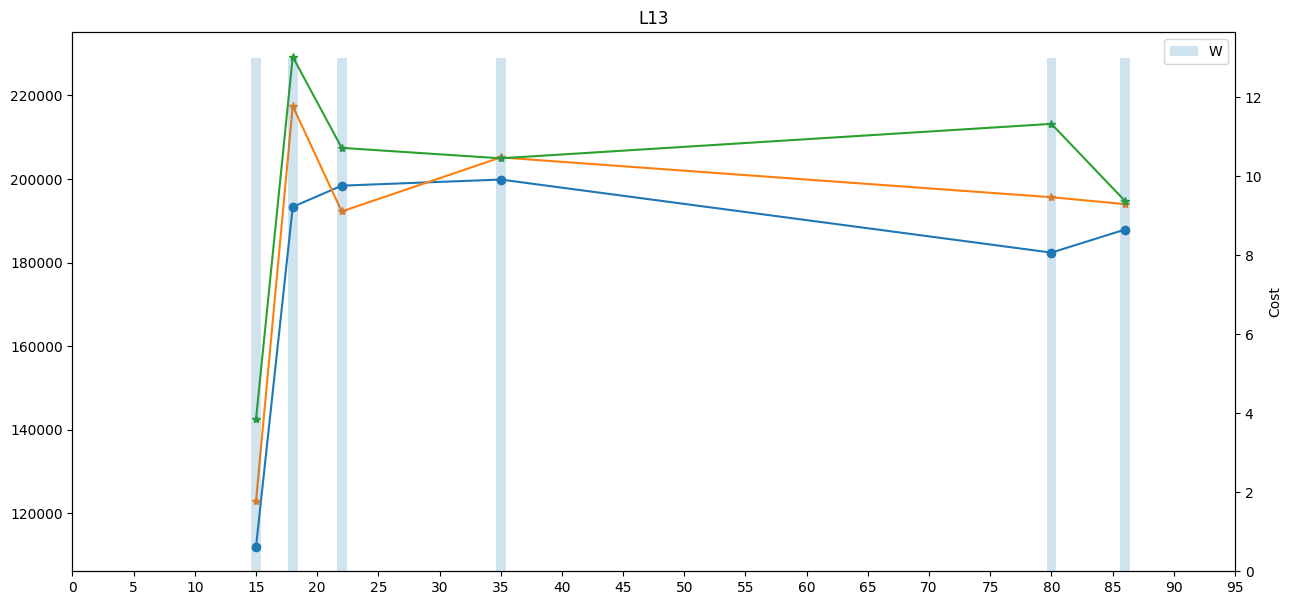

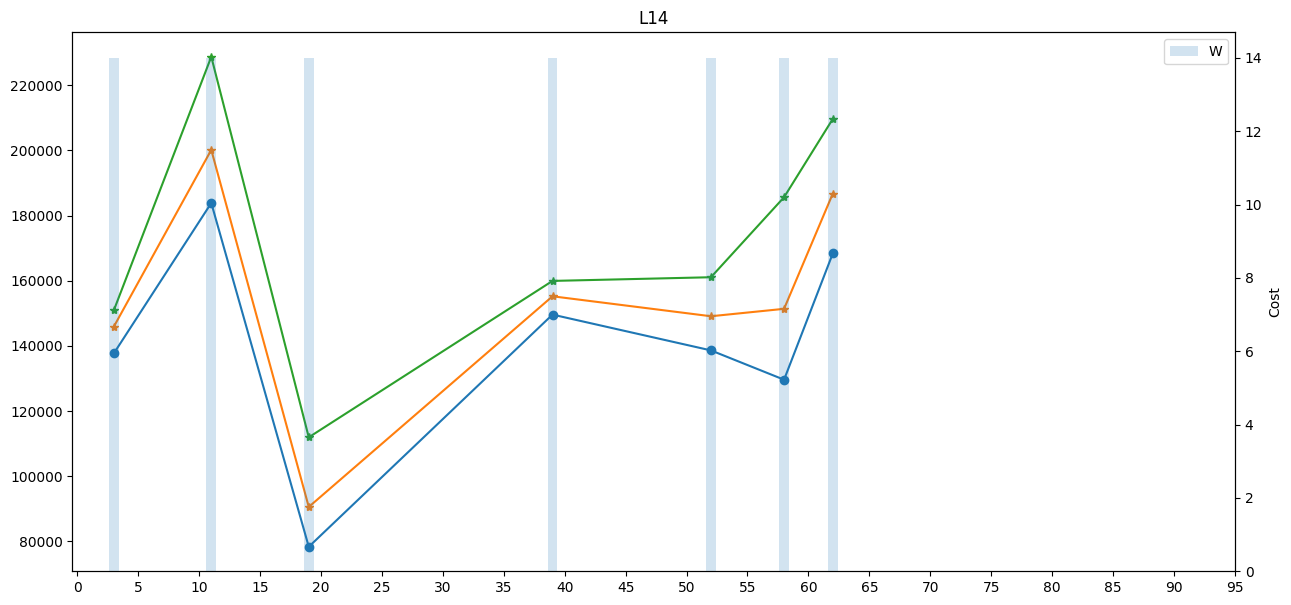

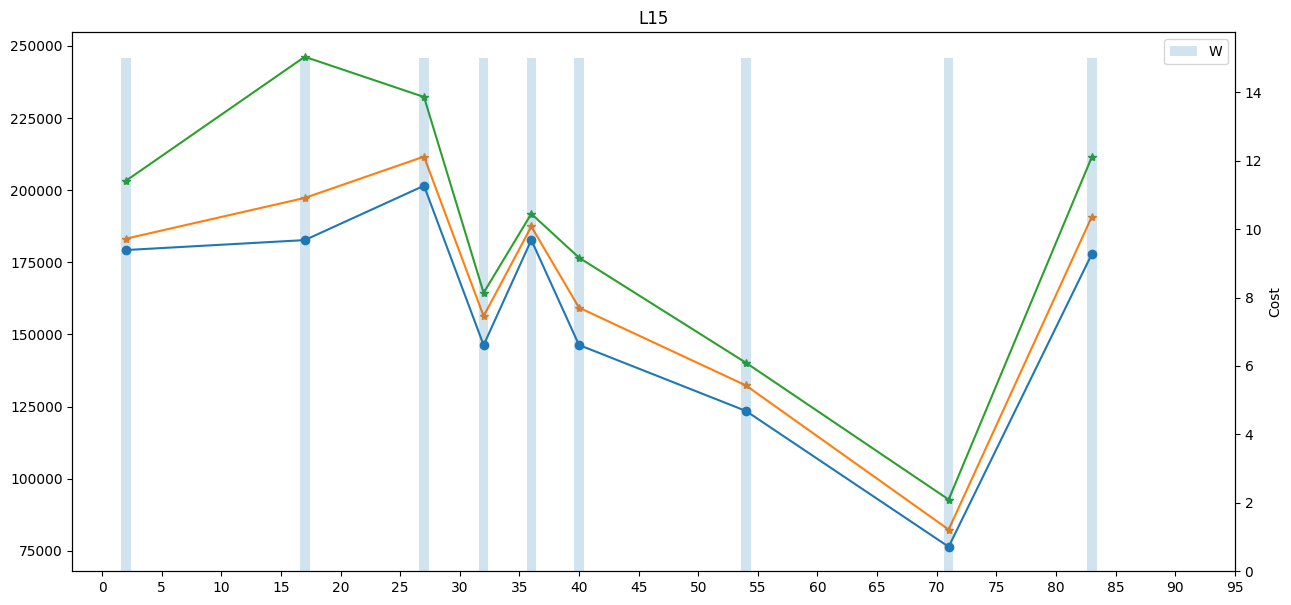

In [30]:
import matplotlib.pyplot as plt

for l_num in range(3, 15 + 1):
    inds = [i for i, v in enumerate(ax2_vals) if v == l_num]
    tmp_ax2_vals = ax2_vals[inds]
    tmp_base_costs = base_costs[inds]
    tmp_target_costs = target_costs[inds]
    tmp_target_costs2 = target_costs2[inds]

    fig = plt.figure(figsize=(15, 7))
    ax1 = fig.add_subplot(111)
    ax1.plot(inds, tmp_base_costs, label="best", marker="o")
    ax1.plot(inds, tmp_target_costs, label="target1", marker="*")
    ax1.plot(inds, tmp_target_costs2, label="targe2", marker="*")

    ax2 = ax1.twinx()
    ax2.bar(inds, tmp_ax2_vals, alpha=0.2, label="W")

    plt.xticks(range(0, FILE_NUM, 5))
    plt.xlabel("File Number")
    plt.ylabel("Cost")
    plt.title(f"L{l_num}")
    plt.legend()
    plt.show()